In [ ]:
from dataclasses import dataclass
from copy import deepcopy
from scipy.optimize import minimize
import numpy as np

@dataclass
class VehicleBicycleModelParams:
    cf_Nprad: float = 0.0
    cr_Nprad: float = 0.0
    mass_kg: float = 0.0
    lf_m: float = 0.0
    lr_m: float = 0.0
    izz_kgm2: float = 0.0
    
G = 9.81
class BicycleModelOptimizer:
    
    def __init__(self, init_vbm_params: VehicleBicycleModelParams, constant_bank_angle_rad=0.0):
        self.init_vbm_params = init_vbm_params
        self.vbm_params = deepcopy(init_vbm_params)
        
        # empty data fields for when the optimization happens
        self.times_s = None
        self.rwas_rad = None
        self.speeds_mps = None
        self.xs_actual = None
        self.ys_actual = None
        self.yrs_actual = None
        
        self.constant_bank_angle_rad = constant_bank_angle_rad
        
    def get_a_b(self, vx_mps):
    
        vx_mps = max(vx_mps, 0.000001)
        cf_Nprad = self.vbm_params.cf_Nprad
        cr_Nprad = self.vbm_params.cr_Nprad
        mass_kg = self.vbm_params.mass_kg
        lf_m = self.vbm_params.lf_m
        lr_m = self.vbm_params.lr_m
        izz_kgm2 = self.vbm_params.izz_kgm2
        
        A = np.array([
            [ -(cf_Nprad + cr_Nprad) / (mass_kg * vx_mps), (cr_Nprad*lr_m - cf_Nprad*lf_m)/(mass_kg * vx_mps) - vx_mps ],
            [ (lr_m*cr_Nprad - lf_m*cf_Nprad) / (izz_kgm2*vx_mps), -(lf_m * lf_m * cf_Nprad + lr_m * lr_m * cr_Nprad)/(izz_kgm2*vx_mps) ]
        ])
        B = np.array([
            [cf_Nprad/mass_kg],
            [cf_Nprad*lf_m/izz_kgm2]
        ])
    
        return A, B
    
    def simulate_vbm(self, times_s, rwas_rad, speeds_mps):
        
        N = len(speeds_mps)
        dts = np.diff(times_s)
        state = np.array([[0.0],[0.0]]) # [vy, yaw_rate]'
        yaws_pred = np.zeros(N)
        xs_pred = np.zeros(N)
        ys_pred = np.zeros(N)
        yaw_rates_pred = np.zeros(N)
        ay_pred = np.zeros(N)
        
        for i in range(0, N-1):
        
            vx = speeds_mps[i]
            
            # get bm equations and step bm forward a timestep
            A, B = self.get_a_b(vx)
            disturbances = np.array([[-G*np.sin(self.constant_bank_angle_rad)],[0.0]])
            state_dot = A @ state + B * rwas_rad[i] + disturbances
            state += state_dot * dts[i]
            
            # get vx, vy, yaw rate, and update ego pose
            vy = state[0]
            yaw_rate = state[1]
            x_last = xs_pred[i]
            y_last = ys_pred[i]
            yaw_last = yaws_pred[i]
            
            dx = vx * dts[i]
            dy = vy * dts[i]
            dyaw = yaw_rate * dts[i]
            
            dx_prime = dx*np.cos(yaw_last) - dy*np.sin(yaw_last)
            dy_prime = dx*np.sin(yaw_last) + dy*np.cos(yaw_last)
            
            xs_pred[i+1] = x_last + dx_prime
            ys_pred[i+1] = y_last + dy_prime
            yaws_pred[i+1] = yaw_last + dyaw
            yaw_rates_pred[i+1] = yaw_rate
            ay_pred[i+1] = state_dot[0] + vx*yaw_rate
            
        return xs_pred, ys_pred, yaws_pred, yaw_rates_pred, ay_pred
    
    # THIS IS THE COST FUNCTION AND I CAN CHANGE MY WEIGHTS HERE :)))))
    def cost_function(self, actual_x, actual_y, actual_yr, predicted_x, predicted_y, predicted_yr):
        rmse_path = np.sqrt(np.mean(np.square(actual_x - predicted_x) + np.square(actual_y - predicted_y)))
        rmse_yawrate = np.sqrt(np.mean(np.square(actual_yr - predicted_yr)))
        return 0.01 * rmse_path + 100 * rmse_yawrate
    
    def simulate_and_get_cost(self, param_scalars):
        
        # update vbm params with newest guess
        self.vbm_params.cf_Nprad = param_scalars[0] * self.init_vbm_params.cf_Nprad
        self.vbm_params.cr_Nprad = param_scalars[1] * self.init_vbm_params.cr_Nprad
        self.vbm_params.mass_kg = param_scalars[2] * self.init_vbm_params.mass_kg
        self.vbm_params.izz_kgm2 = param_scalars[3] * self.init_vbm_params.izz_kgm2
        
        xs_pred, ys_pred, yaws_pred, yaw_rates_pred, ay_pred = self.simulate_vbm(self.times_s, self.rwas_rad, self.speeds_mps)
        cost = self.cost_function(self.xs_actual, self.ys_actual, self.yrs_actual, xs_pred, ys_pred, yaw_rates_pred)
        
        print(f'cost is {cost:.10f} for params {self.vbm_params}')
        
        return cost
    
    def optimize_vbm_params(self, times_s, rwas_rad, speeds_mps, xs_actual, ys_actual, yrs_actual):
        param_scalars = [1, 1, 1, 1]
        param_scalar_bounds = [[0.7, 1.3], [0.7, 1.3], [1.0, 1.000000001], [1.0, 1.000000001]]
        
        self.times_s = times_s
        self.rwas_rad = rwas_rad
        self.speeds_mps = speeds_mps
        self.xs_actual = xs_actual
        self.ys_actual = ys_actual
        self.yrs_actual = yrs_actual
        
        solution = minimize(
            self.simulate_and_get_cost,
            param_scalars,
            bounds=param_scalar_bounds,
            method='Powell'
        )
        best_param_scalars = solution.x

        self.vbm_params.cf_Nprad = best_param_scalars[0] * self.init_vbm_params.cf_Nprad
        self.vbm_params.cr_Nprad = best_param_scalars[1] * self.init_vbm_params.cr_Nprad
        self.vbm_params.mass_kg = best_param_scalars[2] * self.init_vbm_params.mass_kg
        self.vbm_params.izz_kgm2 = best_param_scalars[3] * self.init_vbm_params.izz_kgm2
        
        print(f'best params: {self.vbm_params}')

class VehiclePlantModel:
    
    def __init__(self, params: VehicleBicycleModelParams, major_sample_time_s=0.02, sample_time_s=0.005):
        self.params = params
        self.sample_time_s = sample_time_s
        self.major_sample_time_s = major_sample_time_s
        self.curr_state = np.array([[0.0], [0.0]])
        self.curr_pose = np.array([[0.0], [0.0], [0.0]])
        
    def get_a_b(self, vx_mps):
    
        vx_mps = max(vx_mps, 0.000001)
        cf_Nprad = self.params.cf_Nprad
        cr_Nprad = self.params.cr_Nprad
        mass_kg = self.params.mass_kg
        lf_m = self.params.lf_m
        lr_m = self.params.lr_m
        izz_kgm2 = self.params.izz_kgm2
        
        A = np.array([
            [ -(cf_Nprad + cr_Nprad) / (mass_kg * vx_mps), (cr_Nprad*lr_m - cf_Nprad*lf_m)/(mass_kg * vx_mps) - vx_mps ],
            [ (lr_m*cr_Nprad - lf_m*cf_Nprad) / (izz_kgm2*vx_mps), -(lf_m * lf_m * cf_Nprad + lr_m * lr_m * cr_Nprad)/(izz_kgm2*vx_mps) ]
        ])
        B = np.array([
            [cf_Nprad/mass_kg],
            [cf_Nprad*lf_m/izz_kgm2]
        ])
    
        return A, B
    
    def step_simulation(self, state, pose, delta, speed_mps):
        
        # using forward euler, may need to make this rk4 later
        A, B = self.get_a_b(speed_mps)
        state_dot = A @ state + B * delta
        state += state_dot * self.sample_time_s
        
        # get vx, vy, yaw rate, and update ego pose
        vx = speed_mps
        vy = state[0]
        yaw_rate = state[1]
        yaw = pose[2]
        
        vx_prime = vx*np.cos(yaw) - vy*np.sin(yaw)
        vy_prime = vx*np.sin(yaw) + vy*np.cos(yaw)
        
        pose_dot = np.array([vx_prime, vy_prime, yaw_rate])
        # print('plant pose dot', pose_dot)
        # print('=======')
        # print('plant pose', pose)
        pose += pose_dot * self.sample_time_s
        
        return state, pose
    
    def simulate_over_horizon(self, deltas, speeds_mps):
        
        N = len(deltas)
        for i in range(N):
            self.curr_state, self.curr_pose = self.step_simulation(self.curr_state, self.curr_pose, deltas[i], speeds_mps[i])
    
    def step(self, delta, speed_mps):
        num_timesteps = int(self.major_sample_time_s // self.sample_time_s)
        deltas = [delta] * num_timesteps
        speeds = [speed_mps] * num_timesteps
        self.simulate_over_horizon(deltas, speeds)
        
    def get_curr_pose(self): return self.curr_pose
    def get_curr_state(self): return self.curr_state
        

In [232]:
from dataclasses import dataclass
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.interpolate import CubicSpline
from scipy import interpolate

@dataclass
class VehiclePose:
    x_m: float = 0.0
    y_m: float = 0.0
    theta_rad: float = 0.0
    
def xy_to_plot(x, y): return -y, x

def get_rot_mat(theta_rad):
    
    return np.array([
        [np.cos(theta_rad), np.sin(theta_rad)],
        [-np.sin(theta_rad), np.cos(theta_rad)]
    ])

def cubic_bezier(p0, p1, p2, p3, num_points=100):
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    # Bernstein basis polynomials
    path = (1-t)**3 * p0 + 3*(1-t)**2 * t * p1 + 3*(1-t) * t**2 * p2 + t**3 * p3
    return path

def get_path_length(path):
    x, y = path[0], path[1]
    x_diffs = np.diff(x)
    y_diffs = np.diff(y)
    diffs = np.sqrt(np.square(x_diffs) + np.square(y_diffs))
    cumu_dist = np.cumsum(diffs)
    return cumu_dist[-1]

def cubic_spline(control_points, speed_mps=1.0, sample_rate_hz=25):
    tck,u = interpolate.splprep([control_points[:,0], control_points[:,1]], s=0)
    u_initial_sample = np.arange(0, 1.01, 0.005)
    out = interpolate.splev(u_initial_sample, tck)
    path_length = get_path_length(out)
    u_final_sample = np.arange(0, 1.0, (speed_mps / sample_rate_hz) / path_length)
    path = interpolate.splev(u_final_sample, tck)
    first_derivative = interpolate.splev(u_final_sample, tck, der=1)
    second_derivative = interpolate.splev(u_final_sample, tck, der=2)
    curvature = (first_derivative[0] * second_derivative[1] - first_derivative[1] * second_derivative[0]) / np.power(np.square(first_derivative[0]) + np.square(first_derivative[1]), 1.5)
    return path, curvature

def generate_control_points(final_veh_pose):
    
    point1_x = final_veh_pose.x_m - 2.0
    point1_y = -final_veh_pose.y_m * 0.5
    
    final_pose_offset = np.array([[-abs(final_veh_pose.y_m)*0.75, 0]])
    final_pose_offset_trans = (final_pose_offset @ get_rot_mat(final_veh_pose.theta_rad)).flatten()
    
    # print(final_pose_offset_trans)
    
    point2_x = final_veh_pose.x_m + final_pose_offset_trans[0]
    point2_y = final_veh_pose.y_m + final_pose_offset_trans[1]
    
    point3_x = final_veh_pose.x_m + final_pose_offset_trans[0] / 2
    point3_y = final_veh_pose.y_m + final_pose_offset_trans[1] / 2
    
    point4_x = final_veh_pose.x_m + final_pose_offset_trans[0] *0.35
    point4_y = final_veh_pose.y_m + final_pose_offset_trans[1] *0.35
    
    control_points = [
        (0, 0),
        (point1_x/6, 0.0),
        (point1_x/4, 0.0),
        (point1_x, point1_y),
        (point2_x, point2_y),
        # (point3_x, point3_y),
        (point4_x, point4_y),
        (final_veh_pose.x_m, final_veh_pose.y_m)
    ]
    
    return control_points

def generate_desired_path(final_veh_pose, speed_mps=1.0, sample_rate_hz=25):
    
    control_points = np.array(generate_control_points(final_veh_pose))
    path = cubic_spline(control_points, speed_mps, sample_rate_hz)
    return path

def plot_desired_path(final_veh_pose: VehiclePose):
    
    control_points = generate_control_points(final_veh_pose)
    desired_path, curvature = generate_desired_path(final_veh_pose)
    
    # plt.xlim(-3, 3)
    # plt.ylim(-1, 3)
    plt.grid()
    sc = plt.scatter(-desired_path[1], desired_path[0], c=curvature, cmap='viridis', s=10)

    cbar = plt.colorbar(sc)
    for point in control_points:
        plt.scatter(*xy_to_plot(point[0], point[1]), marker='o', edgecolor='black', s=50, c='green')
    plt.scatter(0, 0, marker='*', edgecolor='black', s=200, c='cyan', label='initial pose')
    plt.scatter(*xy_to_plot(final_veh_pose.x_m, final_veh_pose.y_m), marker='*', edgecolor='black', s=200, c='red', label='final pose')
    plt.gcf().set_size_inches(2, 5)
    # plt.legend()
    


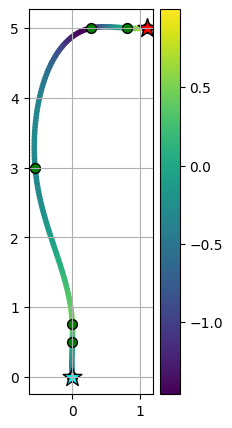

In [233]:
plot_desired_path(VehiclePose(5.0, -1.1, -math.pi/2))


In [301]:
class MpcController:
    
    def __init__(self, params: VehicleBicycleModelParams, horizon: int = 10, speed_mps: float = 1.0, sample_time_hz: float = 50):
        self.sample_time_hz = sample_time_hz
        self.sample_time_s = (1 / self.sample_time_hz)
        self.timestep = 0
        self.params = params
        self.speed_mps = speed_mps
        self.horizon = horizon
        self.A, self.B = self.get_a_b(speed_mps)
        self.curr_state = np.array([[0.0], [0.0]])
        self.curr_pose = np.array([[0.0], [0.0], [0.0]])
        self.last_timestep = 0
        self.path = np.array([[], []])
        self.curvatures = np.array([])
        self.headingErrorGain = 0.001
        self.reset()
        
    def reset(self):
        self.timestep = 0
        self.curr_state = np.array([[0.0], [0.0]])
        self.curr_pose = np.array([[0.0], [0.0], [0.0]])
        
    def set_path(self, path, curvatures):
        self.path = path
        self.curvatures = curvatures
        self.last_timestep = len(self.curvatures)
        self.reset()
        
    def get_a_b(self, vx_mps):
    
        vx_mps = max(vx_mps, 0.000001)
        cf_Nprad = self.params.cf_Nprad
        cr_Nprad = self.params.cr_Nprad
        mass_kg = self.params.mass_kg
        lf_m = self.params.lf_m
        lr_m = self.params.lr_m
        izz_kgm2 = self.params.izz_kgm2
        
        A = np.array([
            [ -(cf_Nprad + cr_Nprad) / (mass_kg * vx_mps), (cr_Nprad*lr_m - cf_Nprad*lf_m)/(mass_kg * vx_mps) - vx_mps ],
            [ (lr_m*cr_Nprad - lf_m*cf_Nprad) / (izz_kgm2*vx_mps), -(lf_m * lf_m * cf_Nprad + lr_m * lr_m * cr_Nprad)/(izz_kgm2*vx_mps) ]
        ])
        B = np.array([
            [cf_Nprad/mass_kg],
            [cf_Nprad*lf_m/izz_kgm2]
        ])
    
        return A, B
    
    def step_simulation(self, state, pose, delta):
        state_dot = self.A @ state + self.B * delta
        state += state_dot * self.sample_time_s
        
        # get vx, vy, yaw rate, and update ego pose
        vx = self.speed_mps
        vy = state[0]
        yaw_rate = state[1]
        yaw = pose[2]
        
        vx_prime = vx*np.cos(yaw) - vy*np.sin(yaw)
        vy_prime = vx*np.sin(yaw) + vy*np.cos(yaw)
        
        pose_dot = np.array([vx_prime, vy_prime, yaw_rate])
        
        # print('mpc pose dot', pose_dot)
        # print('=======')
        # print('mpc pose', pose)
        
        pose += pose_dot * self.sample_time_s
        
        return state, pose
    
    def simulate_over_horizon(self, deltas):
        
        # using forward euler, may need to make this rk4 later
        simulated_state = self.curr_state.copy()
        simulated_pose = self.curr_pose.copy()
        
        N = len(deltas)
        
        xs = np.zeros(N)
        ys = np.zeros(N)
        
        for i in range(N):
            simulated_state, simulated_pose = self.step_simulation(simulated_state, simulated_pose, deltas[i])
            
            # save intermediates for cost function
            xs[i] = simulated_pose[0]
            ys[i] = simulated_pose[1]
            
        return xs, ys
        
    def cost_function(self, desired_x, desired_y, actual_x, actual_y, deltas):
        REGULARIZATION_PENALTY = 0.0007
        squared_path_cost = np.sum(np.square(desired_x - actual_x) + np.square(desired_y - actual_y))
        regularization_cost = np.linalg.norm(deltas)
        # print('squared path:', squared_path_cost, '| regularization', regularization_cost)
        total_cost = squared_path_cost + REGULARIZATION_PENALTY * regularization_cost
        return total_cost
    
    def simulate_and_get_cost(self, deltas):
        N = len(deltas)
        xs, ys = self.simulate_over_horizon(deltas)
        return self.cost_function(self.path[0][self.timestep:self.timestep+N], self.path[1][self.timestep:self.timestep+N], xs, ys, deltas)
    
    def get_init_feedforward_deltas(self, curvatures):
    
        vx_mps = max(self.speed_mps, 0.000001)
        cf_Nprad = self.params.cf_Nprad
        cr_Nprad = self.params.cr_Nprad
        mass_kg = self.params.mass_kg
        lf_m = self.params.lf_m
        lr_m = self.params.lr_m
        izz_kgm2 = self.params.izz_kgm2
        
        kus = (mass_kg / (lf_m + lr_m)) * ((lr_m / cf_Nprad) - (lf_m / cr_Nprad))
        delta_ff = curvatures * ((lf_m + lr_m + kus * vx_mps * vx_mps) + self.headingErrorGain * ((mass_kg * vx_mps * vx_mps * lf_m) / (cr_Nprad * (lf_m + lr_m)) - lr_m))
        
        return delta_ff
        
    def step(self):
        
        # Get horizon length
        init_ts = self.timestep
        final_ts = min(self.timestep + self.horizon, self.last_timestep)
        num_steps = final_ts - init_ts
        
        # Solve MPC optimization problem
        delta_init = self.get_init_feedforward_deltas(self.curvatures[init_ts:final_ts]) # initial guess for control signal
        bounds = [(-0.5, 0.5)] * num_steps
        result = minimize(self.simulate_and_get_cost, delta_init, method='SLSQP', bounds=bounds) # optimization
        
        # increment controller timestep
        self.timestep += 1
        
        # return first rwa in horizon
        curr_delta = result.x[0]
        
        # update simulated current state and vehicle pose (use to get an estimate for vy since that's not measured)
        self.step_simulation(self.curr_state, self.curr_pose, curr_delta)
        
        return curr_delta
        
    def set_curr_state(self, curr_state):
        self.curr_state = curr_state
    
    def set_curr_pose(self, curr_pose):
        # print('curr pose', curr_pose)
        self.curr_pose = curr_pose
        


In [318]:
estimated_params = VehicleBicycleModelParams(cf_Nprad=3.3026000070695702, cr_Nprad=3.819493299820521, mass_kg=2.6181050807024575, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.061255774235714676)
actual_params = VehicleBicycleModelParams(cf_Nprad=3.30, cr_Nprad=3.80, mass_kg=2.62, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.062)

speed_mps = 0.5

desired_pose = VehiclePose(10.0, -2.0, -math.pi/2)
desired_path, curvatures = generate_desired_path(desired_pose, speed_mps=speed_mps)

mpc = MpcController(estimated_params, sample_time_hz=50, horizon=10, speed_mps=speed_mps)
mpc.set_path(desired_path, curvatures)

plant = VehiclePlantModel(actual_params)

# step through number of timesteps in vehicle path
curr_pose = np.array([[0.0], [0.0], [0.0]])

xs, ys, deltas = [], [], []

for i in range(len(curvatures)):
    
    # step controller
    mpc.set_curr_pose(curr_pose)
    curr_delta = mpc.step()
    
    # step simulation
    plant.step(curr_delta, speed_mps)
    curr_pose = plant.get_curr_pose()
    # print(curr_pose)
    xs.append(float(curr_pose[0]))
    ys.append(float(curr_pose[1]))
    deltas.append(float(curr_delta))
    
# print(xs)


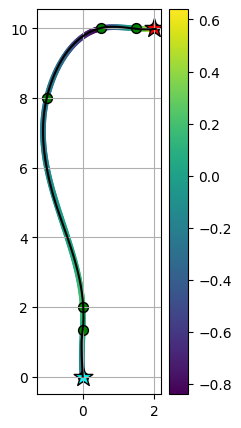

In [319]:
plot_desired_path(desired_pose)
xs, ys = np.array(xs), np.array(ys)
plt.plot(-ys, xs, c='black')


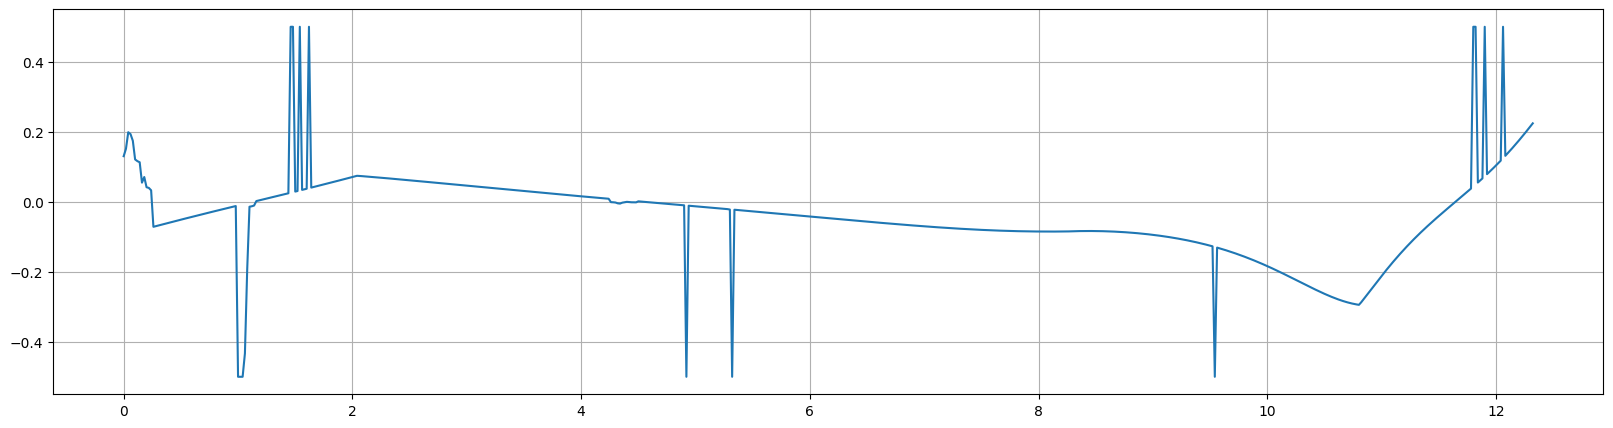

In [ ]:
plt.plot(np.arange(0, len(deltas))*0.02, deltas)
plt.gcf().set_size_inches(20, 5)
plt.grid()
